# Getting Started with SurviveX

This notebook demonstrates the key features of **survivex**, a GPU-accelerated survival analysis library for Python.

[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/plasserre/Survivex/main?labpath=examples%2Fgetting_started.ipynb)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm as sp_norm

from survivex.models import (
    KaplanMeierEstimator,
    NelsonAalenEstimator,
    CoxPHModel,
    WeibullAFTFitter,
    RandomSurvivalForest,
    LogRankTest,
    AalenJohansenFitter,
    AndersenGillModel,
    GradientBoostingSurvivalAnalysis,
)
from survivex.datasets import load_from_lifelines

print("SurviveX loaded successfully!")

/Users/taninzeraati/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


SurviveX loaded successfully!


## 1. Load Example Data

We'll use the Rossi recidivism dataset, which tracks 432 convicts for rearrest over one year.

In [2]:
# Load the Rossi dataset
rossi = load_from_lifelines("rossi")
print(f"Dataset shape: {rossi.shape}")
print(f"Columns: {list(rossi.columns)}")
rossi.head()

📚 Loading 'rossi' from lifelines...
   Original shape: (432, 9)
   Original columns: ['week', 'arrest', 'fin', 'age', 'race', 'wexp', 'mar', 'paro', 'prio']
   Auto-detected time column: 'week'
   Auto-detected event column: 'arrest'
   Event column already in 0/1 format
   ✅ Standardized: time='week', event='arrest'
   Events: 114/432 (26.4%)
   Time range: [1.0, 52.0]
Dataset shape: (432, 13)
Columns: ['week', 'arrest', 'fin', 'age', 'race', 'wexp', 'mar', 'paro', 'prio', 'time', 'original_week', 'event', 'original_arrest']


,week,arrest,fin,age,race,wexp,mar,paro,prio,time,original_week,event,original_arrest
0,20,1,0,27,1,0,0,1,3,20,20,1,1
1,17,1,0,18,1,0,0,1,8,17,17,1,1
2,25,1,0,19,0,1,0,1,13,25,25,1,1
3,52,0,1,23,1,1,1,1,1,52,52,0,0
4,52,0,0,19,0,1,0,1,3,52,52,0,0


In [3]:
# Extract time, event, and covariates
T = rossi['week'].values.astype(float)   # Time to event
E = rossi['arrest'].values.astype(float) # Event indicator (1=arrested, 0=censored)
covariates = ['fin', 'age', 'race', 'wexp', 'mar', 'paro', 'prio']
X = rossi[covariates].values.astype(float)

print(f"n = {len(T)} subjects")
print(f"Events = {int(E.sum())} arrests")
print(f"Censored = {int(len(E) - E.sum())}")

n = 432 subjects
Events = 114 arrests
Censored = 318


## 2. Kaplan-Meier Survival Curve

The Kaplan-Meier estimator provides a non-parametric estimate of the survival function.

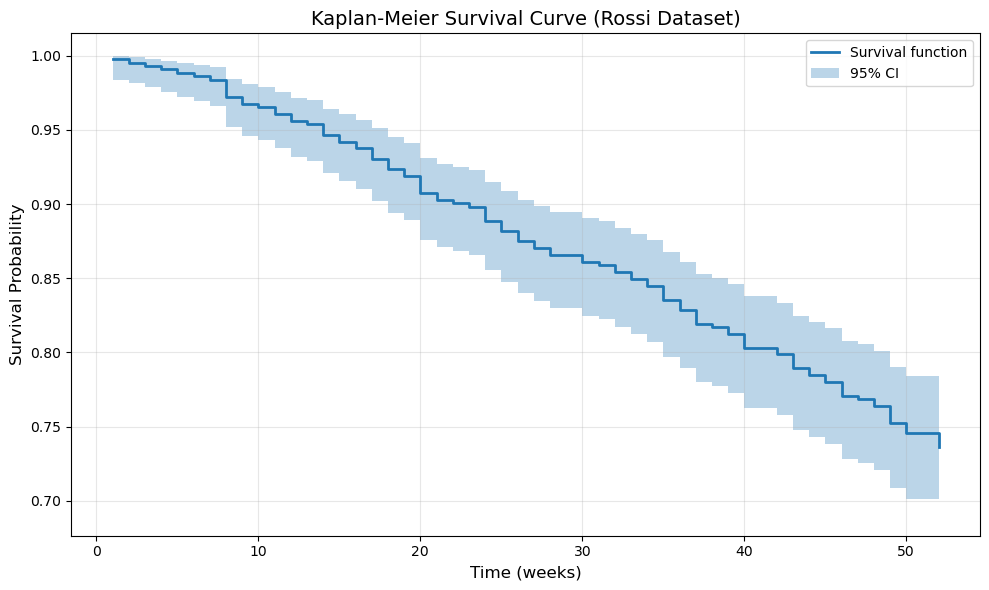

Median survival time: not reached


In [4]:
# Fit Kaplan-Meier estimator
km = KaplanMeierEstimator()
km.fit(T, E)

# Plot survival curve
fig, ax = plt.subplots(figsize=(10, 6))
times = km.timeline_.numpy()
survival = km.survival_function_.numpy()
ci_lower = km.confidence_interval_[:, 0].numpy()
ci_upper = km.confidence_interval_[:, 1].numpy()

ax.step(times, survival, where='post', label='Survival function', linewidth=2)
ax.fill_between(times, ci_lower, ci_upper, alpha=0.3, step='post', label='95% CI')
ax.set_xlabel('Time (weeks)', fontsize=12)
ax.set_ylabel('Survival Probability', fontsize=12)
ax.set_title('Kaplan-Meier Survival Curve (Rossi Dataset)', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

median = km.median_survival_time()
if median is not None:
    print(f"Median survival time: {median:.1f} weeks")
else:
    print("Median survival time: not reached")

## 3. Nelson-Aalen Cumulative Hazard

The Nelson-Aalen estimator provides a non-parametric estimate of the cumulative hazard function H(t) = -log S(t).

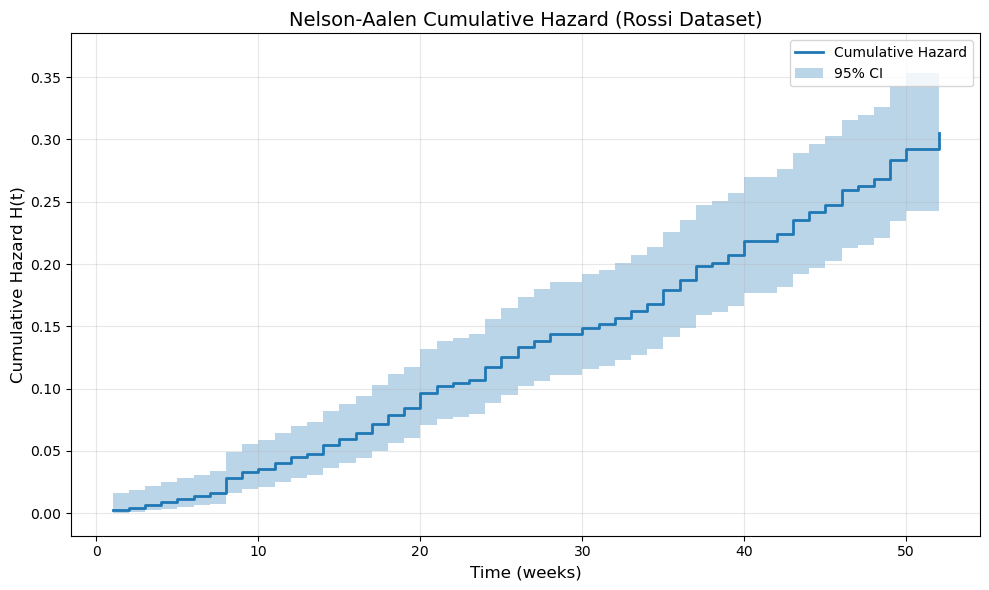

Cumulative Hazard at selected times:
  H(10) = 0.0352
  H(20) = 0.0968
  H(30) = 0.1490
  H(40) = 0.2183
  H(50) = 0.2927


In [5]:
# Fit Nelson-Aalen estimator
na = NelsonAalenEstimator()
na.fit(T, E)

# Plot cumulative hazard
fig, ax = plt.subplots(figsize=(10, 6))
times_na = na.timeline_.numpy()
ch = na.cumulative_hazard_.numpy()
ci_lo = na.confidence_interval_[:, 0].numpy()
ci_hi = na.confidence_interval_[:, 1].numpy()

ax.step(times_na, ch, where='post', label='Cumulative Hazard', linewidth=2)
ax.fill_between(times_na, ci_lo, ci_hi, alpha=0.3, step='post', label='95% CI')
ax.set_xlabel('Time (weeks)', fontsize=12)
ax.set_ylabel('Cumulative Hazard H(t)', fontsize=12)
ax.set_title('Nelson-Aalen Cumulative Hazard (Rossi Dataset)', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

times_eval = np.array([10.0, 20.0, 30.0, 40.0, 50.0])
ch_vals = na.cumulative_hazard_at_times(times_eval).numpy()
print("Cumulative Hazard at selected times:")
for t, h in zip(times_eval, ch_vals):
    print(f"  H({t:.0f}) = {h:.4f}")

## 4. Log-Rank Test

The log-rank test compares survival distributions between groups. Here we test whether financial aid (`fin`) significantly affects rearrest rates.

Log-Rank Test: Financial Aid vs No Financial Aid
  n (no aid):    216  |  events: 66
  n (with aid):  216  |  events: 48
  Test statistic: 3.8376
  p-value:        0.0501
  Interpretation: No significant difference (p >= 0.05)


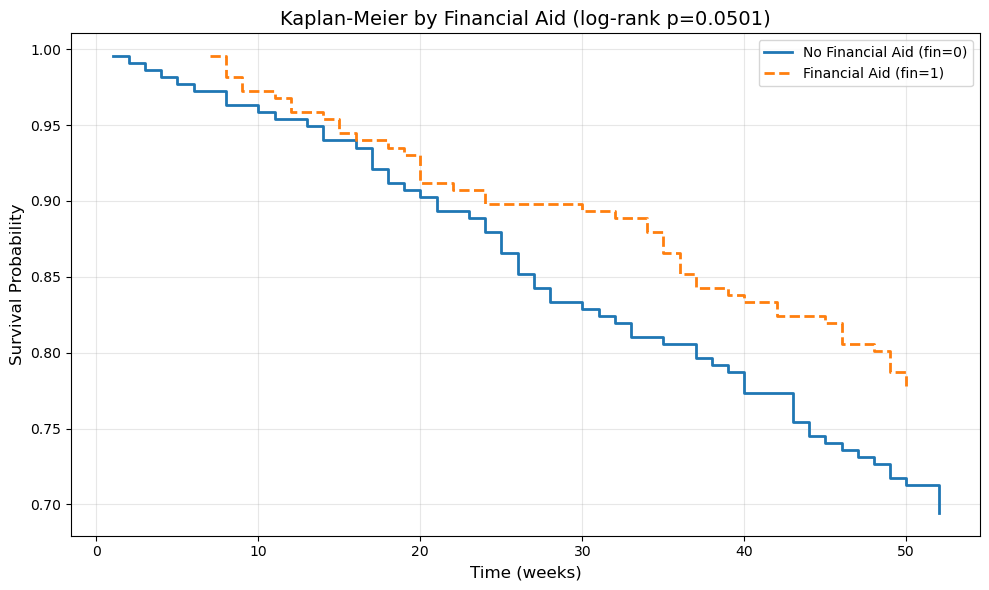

In [6]:
# Split by financial aid group
mask_fin0 = rossi['fin'].values == 0
mask_fin1 = rossi['fin'].values == 1

T_fin0, E_fin0 = T[mask_fin0], E[mask_fin0]
T_fin1, E_fin1 = T[mask_fin1], E[mask_fin1]

# Log-Rank test
lr = LogRankTest()
result = lr.compare(T_fin0, E_fin0, T_fin1, E_fin1)

print(f"Log-Rank Test: Financial Aid vs No Financial Aid")
print(f"  n (no aid):    {mask_fin0.sum()}  |  events: {int(E_fin0.sum())}")
print(f"  n (with aid):  {mask_fin1.sum()}  |  events: {int(E_fin1.sum())}")
print(f"  Test statistic: {result.test_statistic:.4f}")
print(f"  p-value:        {result.p_value:.4f}")
print(f"  Interpretation: {'Significant difference (p < 0.05)' if result.p_value < 0.05 else 'No significant difference (p >= 0.05)'}")

# KM stratified by fin
km_fin0, km_fin1 = KaplanMeierEstimator(), KaplanMeierEstimator()
km_fin0.fit(T_fin0, E_fin0)
km_fin1.fit(T_fin1, E_fin1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.step(km_fin0.timeline_.numpy(), km_fin0.survival_function_.numpy(),
        where='post', label='No Financial Aid (fin=0)', linewidth=2)
ax.step(km_fin1.timeline_.numpy(), km_fin1.survival_function_.numpy(),
        where='post', label='Financial Aid (fin=1)', linewidth=2, linestyle='--')
ax.set_xlabel('Time (weeks)', fontsize=12)
ax.set_ylabel('Survival Probability', fontsize=12)
ax.set_title(f'Kaplan-Meier by Financial Aid (log-rank p={result.p_value:.4f})', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Cox Proportional Hazards Model

The Cox PH model estimates the effect of covariates on the hazard rate.

In [7]:
# Fit Cox PH model
cox = CoxPHModel()
cox.fit(X, T, E)

print("Cox PH Model Results (Rossi dataset):")
print(f"{'Covariate':<12} {'Coefficient':>12} {'Hazard Ratio':>14}")
print("-" * 40)
for name, coef in zip(covariates, cox.coefficients_):
    hr = np.exp(coef)
    print(f"{name:<12} {coef:>12.6f} {hr:>14.4f}")

Cox PH Model Results (Rossi dataset):
Covariate     Coefficient   Hazard Ratio
----------------------------------------
fin             -0.379422         0.6843
age             -0.057438         0.9442
race             0.313900         1.3688
wexp            -0.149796         0.8609
mar             -0.433704         0.6481
paro            -0.084871         0.9186
prio             0.091497         1.0958


## 6. Weibull AFT Model

The Weibull Accelerated Failure Time model assumes a parametric form for the survival distribution.

In [8]:
# Fit Weibull AFT
weibull = WeibullAFTFitter()
weibull.fit(X, T, E)

print(f"Weibull shape parameter (rho): {weibull.rho_:.4f}")
print(f"Weibull baseline scale (lambda_0): {np.exp(weibull.lambda_params_[0]):.4f}")

# Predict survival for a specific covariate profile
X_mean = X.mean(axis=0).reshape(1, -1)
times_pred = np.array([10, 20, 30, 40, 50])
surv_pred = weibull.predict_survival_function(X_mean, times=times_pred)

print(f"\nPredicted survival at mean covariate values:")
for t, s in zip(times_pred, surv_pred):
    print(f"  S({t:2.0f} weeks) = {s:.4f}")

Weibull shape parameter (rho): 1.4038
Weibull baseline scale (lambda_0): 54.0659

Predicted survival at mean covariate values:
  S(10 weeks) = 0.9731
  S(20 weeks) = 0.9305
  S(30 weeks) = 0.8805
  S(40 weeks) = 0.8264
  S(50 weeks) = 0.7704


## 7. Random Survival Forest

Machine learning approach using an ensemble of survival trees.

In [9]:
# Train/test split (70/30)
np.random.seed(42)
n = len(T)
idx = np.random.permutation(n)
train_idx, test_idx = idx[:int(0.7*n)], idx[int(0.7*n):]

X_train, X_test = X[train_idx], X[test_idx]
T_train, T_test = T[train_idx], T[test_idx]
E_train, E_test = E[train_idx], E[test_idx]

# Fit Random Survival Forest
rsf = RandomSurvivalForest(n_estimators=100, max_depth=5, random_state=42)
rsf.fit(X_train, T_train, E_train)

# Evaluate
c_index_rsf = rsf.score(X_test, T_test, E_test)
print(f"Random Survival Forest C-index (test): {c_index_rsf:.4f}")
print(f"OOB C-index: {rsf.oob_score_:.4f}")

# Feature importance
print(f"\nFeature Importance:")
importance = rsf.feature_importances_
for name, imp in sorted(zip(covariates, importance), key=lambda x: -x[1]):
    print(f"  {name}: {imp:.4f}")

Random Survival Forest C-index (test): 0.5753
OOB C-index: 0.6576

Feature Importance:
  age: 0.4836
  prio: 0.2486
  wexp: 0.1192
  paro: 0.0443
  fin: 0.0428
  mar: 0.0378
  race: 0.0237


## 8. Gradient Boosting Survival

Gradient boosting optimizes the Cox partial likelihood iteratively, often achieving better discrimination than RSF on tabular data.

In [10]:
# Fit Gradient Boosting Survival
gb = GradientBoostingSurvivalAnalysis(
    n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42
)
gb.fit(X_train, T_train, E_train)

c_index_gb = gb.score(X_test, T_test, E_test)
print(f"Gradient Boosting C-index (test): {c_index_gb:.4f}")
print(f"RSF C-index (test):               {c_index_rsf:.4f}")

# Feature importance comparison
print(f"\nFeature Importance Comparison:")
print(f"{'Covariate':<10} {'Grad. Boost':>14} {'RSF':>10}")
print("-" * 36)
gb_imp  = gb.feature_importances_
rsf_imp = rsf.feature_importances_
for name, gi, ri in sorted(zip(covariates, gb_imp, rsf_imp), key=lambda x: -x[1]):
    print(f"{name:<10} {gi:>14.4f} {ri:>10.4f}")

Gradient Boosting C-index (test): 0.5925
RSF C-index (test):               0.5753

Feature Importance Comparison:
Covariate     Grad. Boost        RSF
------------------------------------
age                0.4990     0.4836
prio               0.2822     0.2486
wexp               0.1138     0.1192
mar                0.0430     0.0378
paro               0.0263     0.0443
fin                0.0215     0.0428
race               0.0142     0.0237


## 9. Competing Risks — Aalen-Johansen Estimator

When subjects can experience one of several mutually exclusive events, standard KM overestimates the incidence. The Aalen-Johansen estimator computes the **Cumulative Incidence Function (CIF)** for each event type correctly.

Here we simulate a dataset where patients can experience event 1 (primary event) or event 2 (competing event).

n=500  |  event 1: 224  |  event 2: 160  |  censored: 116


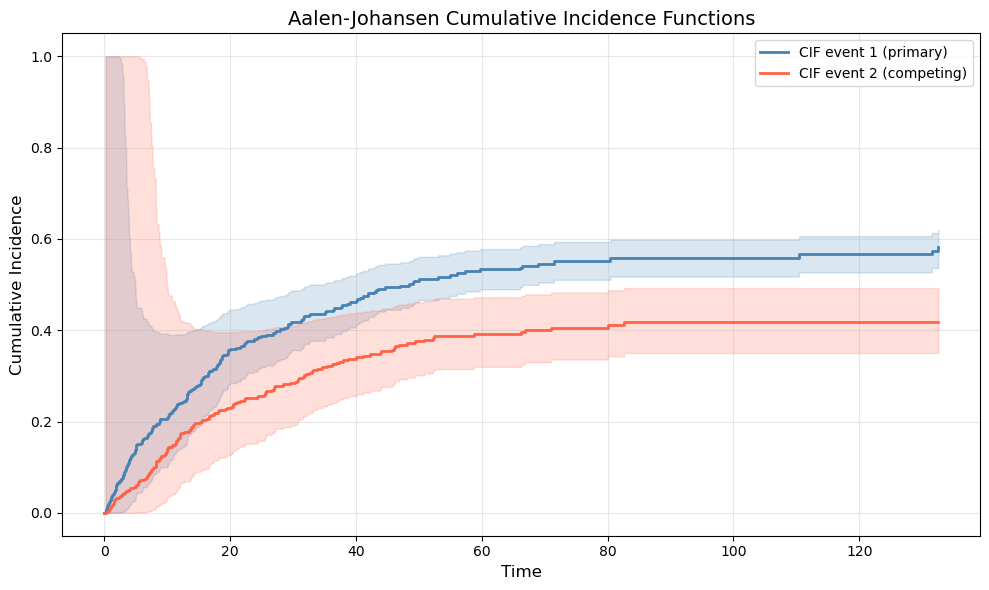


CIF at t=50:
  Event 1: 0.5125
  Event 2: 0.3755
  Sum:     0.8880  (must be <= 1)


In [11]:
np.random.seed(42)
n_cr = 500

# Simulate competing risks: event 1 (primary), event 2 (competing), 0 (censored)
T1 = np.random.exponential(scale=40, size=n_cr)  # time to primary event
T2 = np.random.exponential(scale=60, size=n_cr)  # time to competing event
C  = np.random.exponential(scale=80, size=n_cr)  # censoring time

T_cr = np.minimum(np.minimum(T1, T2), C)
E_cr = np.where(T1 <= T2, np.where(T1 <= C, 1, 0),
                           np.where(T2 <= C, 2, 0))

print(f"n={n_cr}  |  event 1: {(E_cr==1).sum()}  |  event 2: {(E_cr==2).sum()}  |  censored: {(E_cr==0).sum()}")

# Fit Aalen-Johansen for each event type
aj1 = AalenJohansenFitter()
aj1.fit(T_cr, E_cr, event_of_interest=1)

aj2 = AalenJohansenFitter()
aj2.fit(T_cr, E_cr, event_of_interest=2)

# Plot CIFs
fig, ax = plt.subplots(figsize=(10, 6))

t1 = aj1.timeline_.cpu().numpy()
cif1 = aj1.cumulative_incidence_.cpu().numpy()
ci1_lo = aj1.confidence_interval_lower_.cpu().numpy()
ci1_hi = aj1.confidence_interval_upper_.cpu().numpy()

t2 = aj2.timeline_.cpu().numpy()
cif2 = aj2.cumulative_incidence_.cpu().numpy()
ci2_lo = aj2.confidence_interval_lower_.cpu().numpy()
ci2_hi = aj2.confidence_interval_upper_.cpu().numpy()

ax.step(t1, cif1, where='post', linewidth=2, color='steelblue', label='CIF event 1 (primary)')
ax.fill_between(t1, ci1_lo, ci1_hi, alpha=0.2, step='post', color='steelblue')

ax.step(t2, cif2, where='post', linewidth=2, color='tomato', label='CIF event 2 (competing)')
ax.fill_between(t2, ci2_lo, ci2_hi, alpha=0.2, step='post', color='tomato')

ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Cumulative Incidence', fontsize=12)
ax.set_title('Aalen-Johansen Cumulative Incidence Functions', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nCIF at t=50:")
idx1 = np.searchsorted(t1, 50, side='right') - 1
idx2 = np.searchsorted(t2, 50, side='right') - 1
print(f"  Event 1: {cif1[idx1]:.4f}")
print(f"  Event 2: {cif2[idx2]:.4f}")
print(f"  Sum:     {cif1[idx1] + cif2[idx2]:.4f}  (must be <= 1)")

## 10. Recurrent Events — Andersen-Gill Model

When subjects can experience the same event multiple times (infections, hospitalizations, relapses), standard survival models are inappropriate. The Andersen-Gill model extends Cox regression to counting process format.

This is a key differentiator of survivex — **recurrent event models are not available in lifelines**.

In [12]:
np.random.seed(42)
n_subj = 150

# Simulate recurrent infections: treatment reduces event rate by ~40%
subject_ids   = np.arange(n_subj)
event_times_list  = []
event_status_list = []
covariates_re = np.zeros((n_subj, 2))   # [treatment, age]

for i in range(n_subj):
    treatment = int(i % 2)              # alternating treatment/control
    age       = np.random.normal(35, 8)
    covariates_re[i] = [treatment, age]

    base_rate = 0.08 * (1 - 0.4 * treatment)
    times, status = [], []
    t = 0.0
    while t < 52:
        gap = np.random.exponential(1.0 / base_rate)
        t  += gap
        if t < 52:
            times.append(t);  status.append(1)
        else:
            times.append(52); status.append(0); break
    if not times:
        times, status = [52.0], [0]
    event_times_list.append(np.array(times))
    event_status_list.append(np.array(status))

total_events = sum(s.sum() for s in event_status_list)
print(f"n subjects: {n_subj}  |  total recurrent events: {int(total_events)}")
print(f"Avg events per subject: {total_events/n_subj:.2f}")

# Fit Andersen-Gill model
ag = AndersenGillModel(tie_method='efron')
ag.fit_simple(
    subject_ids=subject_ids,
    event_times=event_times_list,
    event_status=event_status_list,
    covariates=covariates_re
)

coef_names = ['treatment', 'age']
z_ag = ag.coefficients_ / ag.standard_errors_
p_ag = 2 * (1 - sp_norm.cdf(np.abs(z_ag)))

print(f"\nAndersen-Gill Model Results (robust standard errors)")
print(f"{'Covariate':<12} {'Coef':>10} {'HR':>10} {'Robust SE':>12} {'p-value':>10}")
print("-" * 56)
for name, coef, se, p in zip(coef_names, ag.coefficients_, ag.standard_errors_, p_ag):
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    print(f"{name:<12} {coef:>10.4f} {np.exp(coef):>10.4f} {se:>12.4f} {p:>10.4f} {sig}")
print(f"\nInterpretation: treatment HR = {np.exp(ag.coefficients_[0]):.3f} "
      f"({'reduces' if ag.coefficients_[0]<0 else 'increases'} event rate)")

n subjects: 150  |  total recurrent events: 513
Avg events per subject: 3.42

Andersen-Gill Model Results (robust standard errors)
Covariate          Coef         HR    Robust SE    p-value
--------------------------------------------------------
treatment       -0.4724     0.6235       0.0988     0.0000 ***
age             -0.0003     0.9997       0.0056     0.9558 

Interpretation: treatment HR = 0.624 (reduces event rate)


## 11. Validation against lifelines

Verify that survivex Cox PH coefficients match the reference implementation to machine precision.

In [13]:
from lifelines import CoxPHFitter

# Fit lifelines Cox PH
df = rossi[covariates + ['week', 'arrest']].copy()
cox_ll = CoxPHFitter(penalizer=0.0)
cox_ll.fit(df, duration_col='week', event_col='arrest')

# Compare coefficients
print("Coefficient Comparison: SurviveX vs lifelines")
print("=" * 50)
print(f"{'Covariate':<12} {'SurviveX':>12} {'lifelines':>12} {'Diff':>12}")
print("-" * 50)

max_diff = 0
for i, name in enumerate(covariates):
    sx_coef = cox.coefficients_[i]
    ll_coef = cox_ll.params_[name]
    diff = abs(sx_coef - ll_coef)
    max_diff = max(max_diff, diff)
    print(f"{name:<12} {sx_coef:>12.6f} {ll_coef:>12.6f} {diff:>12.2e}")

print("-" * 50)
print(f"Maximum coefficient difference: {max_diff:.2e}")
print(f"Validation: {'PASS' if max_diff < 1e-6 else 'FAIL'}")

Coefficient Comparison: SurviveX vs lifelines
Covariate        SurviveX    lifelines         Diff
--------------------------------------------------
fin             -0.379422    -0.379422     7.68e-10
age             -0.057438    -0.057438     2.65e-09
race             0.313900     0.313900     5.75e-10
wexp            -0.149796    -0.149796     4.15e-09
mar             -0.433704    -0.433704     3.25e-09
paro            -0.084871    -0.084871     1.87e-09
prio             0.091497     0.091497     7.50e-10
--------------------------------------------------
Maximum coefficient difference: 4.15e-09
Validation: PASS


## Summary

This notebook demonstrated the key features of **survivex**:

| # | Model | Type | Key Output |
|---|-------|------|------------|
| 2 | Kaplan-Meier | Non-parametric | Survival function S(t) |
| 3 | Nelson-Aalen | Non-parametric | Cumulative hazard H(t) |
| 4 | Log-Rank Test | Hypothesis test | p-value for group comparison |
| 5 | Cox PH | Semi-parametric | Hazard ratios per covariate |
| 6 | Weibull AFT | Parametric | Shape/scale parameters |
| 7 | Random Survival Forest | Machine learning | C-index, feature importance |
| 8 | Gradient Boosting | Machine learning | C-index, feature importance |
| 9 | Aalen-Johansen | Competing risks | CIF per event type |
| 10 | Andersen-Gill | Recurrent events | HR for repeated events |
| 11 | Validation | Comparison | Matches lifelines to <1e-6 |

For more information and additional models (frailty, multi-state), see the [full documentation](https://github.com/plasserre/Survivex).